<a href="https://colab.research.google.com/github/juanselles/book/blob/main/10_Image_Classification_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Imágenes de entrenamiento: (60000, 28, 28)
Imágenes de prueba: (10000, 28, 28)


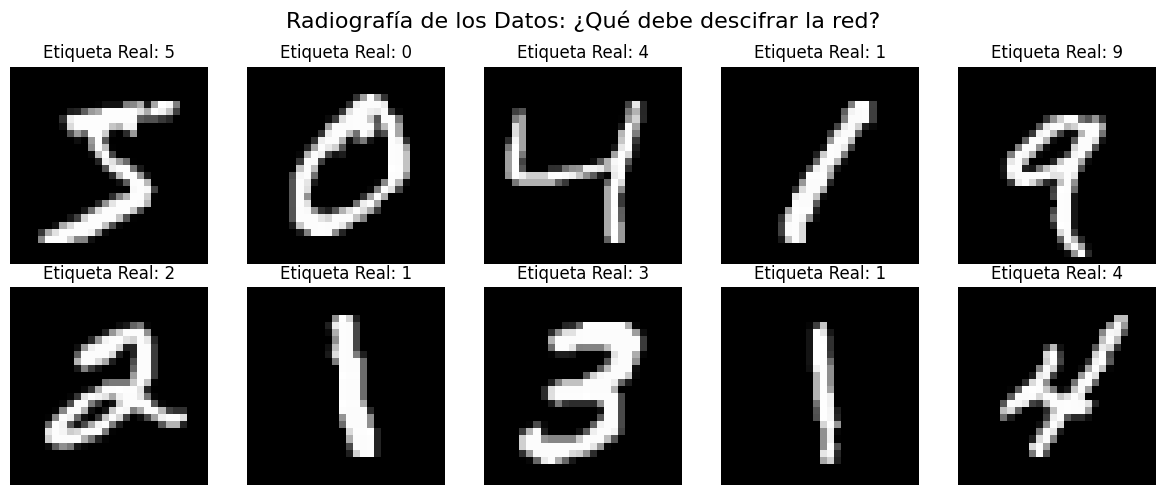

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Iniciando entrenamiento del modelo...

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9164 - loss: 0.2908 - val_accuracy: 0.9536 - val_loss: 0.1620
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9627 - loss: 0.1278 - val_accuracy: 0.9658 - val_loss: 0.1162
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9738 - loss: 0.0883 - val_accuracy: 0.9678 - val_loss: 0.1029
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9806 - loss: 0.0655 - val_accuracy: 0.9684 - val_loss: 0.1077
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9846 - loss: 0.0504 - val_accuracy: 0.9737 - val_loss: 0.0879
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9884 - loss: 0.0399 - val_accuracy: 0.9727 - val_loss: 0.0908
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9906 - loss: 0.0307 - val_accuracy: 0.9725 - val_loss: 0.0960
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 

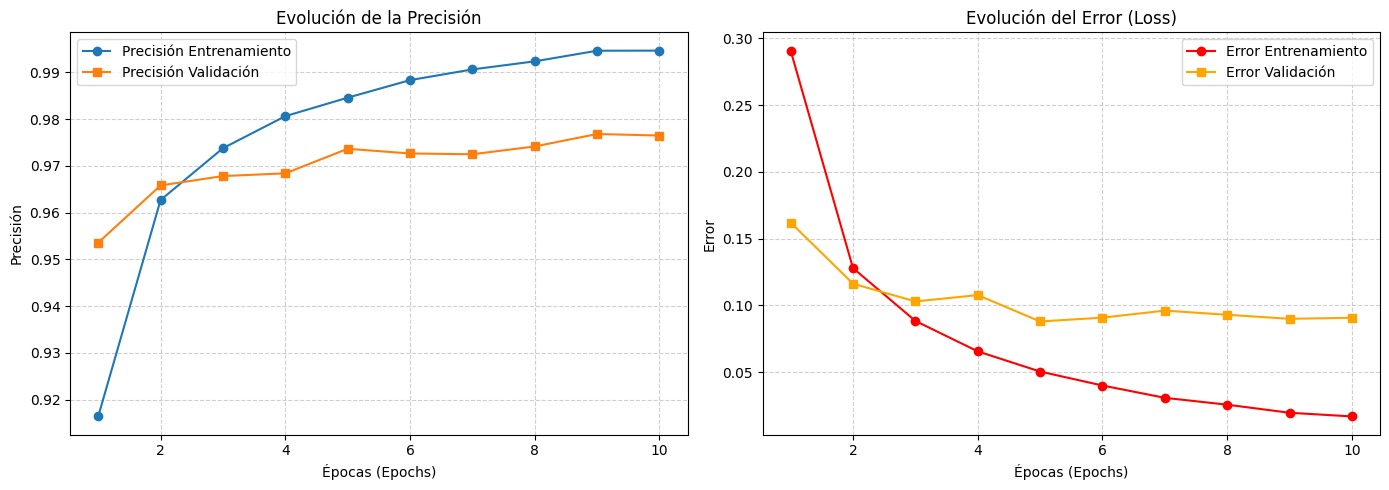


Precisión en el examen final (Test Accuracy): 97.94%

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


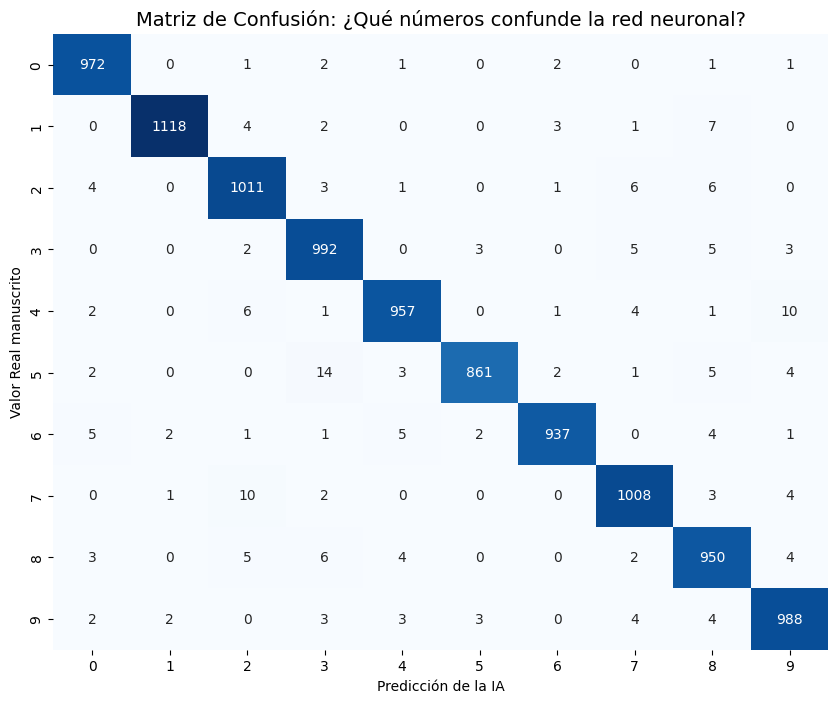

In [1]:
# ==============================================================================
# CAPÍTULO 10: DEEP LEARNING (REDES NEURONALES) - CASO PRÁCTICO
# Clasificación de imágenes: Reconocimiento de dígitos manuscritos (MNIST)
# ==============================================================================

# Importamos las librerías necesarias
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==============================================================================
# FASE 1: EXPLORACIÓN VISUAL DE LOS DATOS
# Antes de que la red neuronal procese los datos, debemos entender qué forma tienen.
# ==============================================================================

# 1. Cargamos el dataset MNIST (70.000 imágenes de números del 0 al 9)
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# 2. El escalado es fundamental en Deep Learning.
# Los píxeles tienen un valor de 0 (negro) a 255 (blanco).
# Dividimos entre 255.0 para que la red trabaje con números entre 0 y 1,
# evitando que los gradientes matemáticos "exploten" durante el entrenamiento.
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Imágenes de entrenamiento: {X_train.shape}")
print(f"Imágenes de prueba: {X_test.shape}")

# 3. Visualizamos los primeros 10 ejemplos del dataset para entender el reto
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Usamos cmap='gray' para ver las imágenes en escala de grises
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Etiqueta Real: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Radiografía de los Datos: ¿Qué debe descifrar la red?", fontsize=16)
plt.tight_layout()
plt.show()

# ==============================================================================
# FASE 2: CONSTRUCCIÓN Y ENTRENAMIENTO DE LA RED (CON RAYOS X)
# ==============================================================================

# 1. Diseñamos la arquitectura de la red (El cerebro)
model = keras.Sequential([
    # Capa de Entrada: "Aplastamos" la imagen 2D (28x28) a un vector 1D (784)
    keras.layers.Flatten(input_shape=(28, 28)),

    # Capa Oculta: 128 neuronas. Usamos ReLU para apagar las que no aporten valor.
    keras.layers.Dense(128, activation='relu'),

    # Capa de Salida: 10 neuronas (una por cada posible número del 0 al 9).
    # Softmax transforma el output en un porcentaje de probabilidad.
    keras.layers.Dense(10, activation='softmax')
])

# 2. Compilamos el modelo
# 'sparse_categorical_crossentropy' castiga matemáticamente al modelo cuando
# su porcentaje de probabilidad no coincide con la etiqueta real.
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. Entrenamos el modelo guardando su "historial" médico
print("\nIniciando entrenamiento del modelo...\n")
# validation_split=0.2 reserva el 20% de los datos de entrenamiento para
# evaluar al modelo en cada época (sin usar los datos del examen final).
historial = model.fit(X_train, y_train, epochs=10, validation_split=0.2)

# ==============================================================================
# FASE 3: LA CURVA DE APRENDIZAJE
# ¿Está el modelo memorizando (overfitting) o realmente está aprendiendo?
# ==============================================================================

# Extraemos las métricas del historial
acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history['loss']
val_loss = historial.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión Entrenamiento', marker='o')
plt.plot(epochs_range, val_acc, label='Precisión Validación', marker='s')
plt.title('Evolución de la Precisión')
plt.xlabel('Épocas (Epochs)')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico de Pérdida (Loss / Error)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Error Entrenamiento', marker='o', color='red')
plt.plot(epochs_range, val_loss, label='Error Validación', marker='s', color='orange')
plt.title('Evolución del Error (Loss)')
plt.xlabel('Épocas (Epochs)')
plt.ylabel('Error')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ==============================================================================
# FASE 4: ANÁLISIS FORENSE DE ERRORES (MATRIZ DE CONFUSIÓN)
# Ningún modelo es perfecto. Vamos a descubrir exactamente dónde se confunde.
# ==============================================================================

# 1. Evaluamos el modelo con los datos del examen final (Test)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nPrecisión en el examen final (Test Accuracy): {test_acc * 100:.2f}%\n")

# 2. Hacemos que el modelo prediga todos los datos de prueba
# Esto devuelve probabilidades, así que buscamos la posición del valor más alto (argmax)
predicciones_prob = model.predict(X_test)
predicciones_etiquetas = np.argmax(predicciones_prob, axis=1)

# 3. Calculamos la Matriz de Confusión
cm = confusion_matrix(y_test, predicciones_etiquetas)

# 4. Dibujamos el Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión: ¿Qué números confunde la red neuronal?', fontsize=14)
plt.xlabel('Predicción de la IA')
plt.ylabel('Valor Real manuscrito')
plt.show()

# Análisis didáctico para el alumno:
# Observa los números fuera de la diagonal principal.
# ¿Confunde a menudo el modelo el '7' con el '1'? ¿O el '9' con el '4'?
# Esto demuestra que la red neuronal comete errores visuales muy similares a los humanos.